#Protein Structure Prediction using Embeddings

##**Introduction**

Understanding protein structure is a central challenge in computational biology. In this notebook, we combine modern representation learning with sequence modeling to tackle secondary structure prediction. We leverage embeddings from a pretrained protein sequence transformer—trained via masked residue prediction—to capture rich biochemical context, and feed them into an LSTM-based classifier trained on a smaller labeled dataset.

**Dataset**:
The secondary protein structure, i.e. set of shapes associated with certain amino acid sequences, is modeled based on the data provided by [ics.uci.edu](https://archive.ics.uci.edu/ml/datasets/Molecular+Biology+%28Protein+Secondary+Structure%29).
A total of 91 proteins, with variable sequence lengths,  made up of amino acids (20 types) are analyzed.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdb
import seaborn as sns

In [ ]:
#Check Input
dataset =pd.read_csv("protein-secondary-structure.train",sep= " ",skiprows=range(7))
print('\n\n')
print(dataset.head(),'\n')




  <>
G  _
V  _
G  _
T  _
V  _ 



In [ ]:
#Functions
def getSeq(fname):
    fin = open(fname,"r")
    aa  = []
    sh  = []
    nseq= 0
    a_,s_ = [],[]

    for iline in fin.readlines():
      if '#' not in iline and len(iline)>1:
        if '<>' in iline:
          #print("Start")
          a_ = []
          s_ = []

        elif 'end' in iline:
          nseq = nseq+1
          aa.append(a_)
          sh.append(s_)
          #print("End")

        else:
          x1,x2 = iline.split()
          a_.append(x1)
          x2 = 'c' if x2=='_' else x2
          s_.append(x2)

    print ("File: ",fname," ",nseq, "sequences processed")
    return aa,sh

In [ ]:
#Get sequences
aa_train, sh_train = getSeq("protein-secondary-structure.train")
aa_test , sh_test  = getSeq("protein-secondary-structure.test")
###
print("Combining Test and Train from given data")
aa = aa_train+aa_test
sh = sh_train+sh_test
print (f"Total {len(aa)} samples.")

print("Creating new Test and Train samples")
#Make New sequences
from sklearn.model_selection import train_test_split
aa_train,aa_test,sh_train, sh_test = train_test_split(aa,sh,test_size=0.15)
print(f"Train:{len(aa_train):4d} Test:{len(aa_test):4d}")
print(f"Train:{len(sh_train):4d} Test:{len(sh_test):4d}")

File:  protein-secondary-structure.train   91 sequences processed
File:  protein-secondary-structure.test   15 sequences processed
Combining Test and Train from given data
Total 106 samples.
Creating new Test and Train samples
Train:  90 Test:  16
Train:  90 Test:  16


Sequence Min/Avg/Max:  26 145.5 498


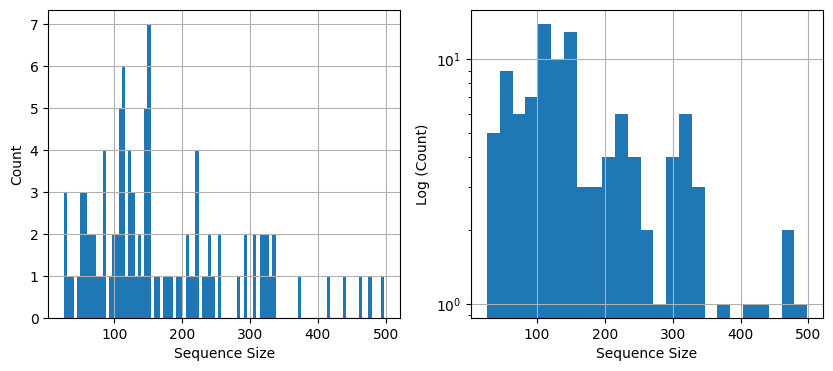

In [ ]:
##Plot data
seq_sizes =[]
for i in aa:
  seq_sizes.append(len(i))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(seq_sizes,bins=100)
axes[0].set_xlabel("Sequence Size")
axes[0].set_ylabel("Count")
axes[0].grid(True)

##
axes[1].hist(seq_sizes,bins=25)
axes[1].set_xlabel("Sequence Size")
axes[1].set_ylabel("Log (Count)")
axes[1].set_yscale("log")
axes[1].grid(True)

print("Sequence Min/Avg/Max: ",np.min(seq_sizes),np.median(seq_sizes),np.max(seq_sizes))

In [ ]:
##Check AA residue frequency
from collections import Counter, OrderedDict
from itertools import chain

# Flatten the list of lists
flat_data = list(chain.from_iterable(aa))
flat_sh   = list(chain.from_iterable(sh))


# Count frequencies
global_freq = Counter(flat_data)
global_freq = OrderedDict(sorted(global_freq.items()))
print(global_freq)
global_freq_sh = Counter(flat_sh)
global_freq_sh = OrderedDict(sorted(global_freq_sh.items()))
print(global_freq_sh)

normalized_freq_by_size = {}
total_aa = 0
for size, counter in global_freq.items():
    #print (size,counter)
    total_aa += counter

normalized_freq_by_size = {k: v / total_aa for k, v in global_freq.items()}
print (normalized_freq_by_size)
print("Total AA types: ",len(normalized_freq_by_size))


OrderedDict({'A': 1589, 'C': 422, 'D': 1053, 'E': 907, 'F': 696, 'G': 1617, 'H': 424, 'I': 871, 'K': 1253, 'L': 1395, 'M': 297, 'N': 834, 'P': 835, 'Q': 648, 'R': 633, 'S': 1335, 'T': 1139, 'V': 1363, 'W': 273, 'Y': 646})
OrderedDict({'c': 10084, 'e': 3496, 'h': 4650})
{'A': 0.08716401535929787, 'C': 0.023148656061437192, 'D': 0.057761930883159625, 'E': 0.04975315414152496, 'F': 0.03817882611080636, 'G': 0.08869994514536478, 'H': 0.023258365331870545, 'I': 0.04777838727372463, 'K': 0.06873285792649479, 'L': 0.07652221612726276, 'M': 0.016291826659352714, 'N': 0.045748765770707626, 'P': 0.0458036204059243, 'Q': 0.03554580362040592, 'R': 0.03472298409215579, 'S': 0.07323093801426221, 'T': 0.06247942951179375, 'V': 0.07476686780032912, 'W': 0.014975315414152496, 'Y': 0.03543609434997257}
Total AA types:  20


Text(0, 0.5, 'Global Frequency')

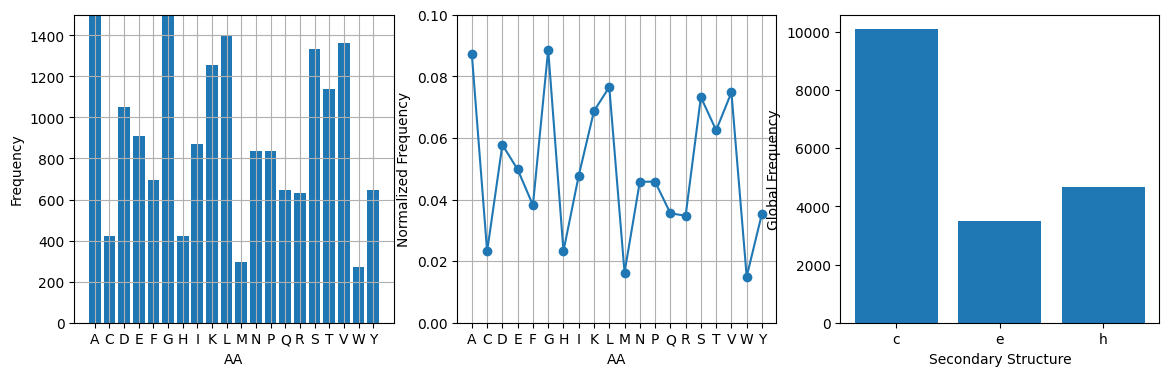

In [ ]:
aa_labels = list(global_freq.keys())
aa_freq   = list(global_freq.values())
aa_freq_n = list(normalized_freq_by_size.values())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(aa_labels,aa_freq)
axes[0].set_xlabel("AA")
axes[0].set_ylabel("Frequency")
axes[0].grid(True)
axes[0].set_ylim(0,1500)
##
axes[1].plot(aa_labels,aa_freq_n, marker='o')
axes[1].set_xlabel("AA")
axes[1].set_ylabel("Normalized Frequency")
axes[1].grid(True)
axes[1].set_ylim(0,0.1)
##
sh_labels = list(global_freq_sh.keys())
sh_freq   = list(global_freq_sh.values())
axes[2].bar(sh_labels,sh_freq)
axes[2].set_xlabel("Secondary Structure")
axes[2].set_ylabel("Global Frequency")

In [ ]:
##Create token dictionary
unq_aa = global_freq.keys()
unq_sh = global_freq_sh.keys()
from secondary_struct_fcns import token2idx,idx2token

stoken2idx = {'[PAD]': 0, '[CLS]': 1, '[MASK]': 2, 'e':3, 'h':4,'c':5}
idx2stoken = {0: '[PAD]', 1: '[CLS]', 2: '[MASK]',  3:'e', 4:'h',5:'c'}
print(token2idx)
print(idx2token)
print(stoken2idx)

{'[PAD]': 0, '[CLS]': 1, '[MASK]': 2, 'A': 3, 'B': 4, 'C': 5, 'D': 6, 'E': 7, 'F': 8, 'G': 9, 'H': 10, 'I': 11, 'K': 12, 'L': 13, 'M': 14, 'N': 15, 'P': 16, 'Q': 17, 'R': 18, 'S': 19, 'T': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}
{0: '[PAD]', 1: '[CLS]', 2: '[MASK]', 3: 'A', 4: 'B', 5: 'C', 6: 'D', 7: 'E', 8: 'F', 9: 'G', 10: 'H', 11: 'I', 12: 'K', 13: 'L', 14: 'M', 15: 'N', 16: 'P', 17: 'Q', 18: 'R', 19: 'S', 20: 'T', 21: 'V', 22: 'W', 23: 'X', 24: 'Y', 25: 'Z'}
{'[PAD]': 0, '[CLS]': 1, '[MASK]': 2, 'e': 3, 'h': 4, 'c': 5}


In [ ]:
##What is distribution of sequence length for each shape
# Function to extract contiguous segments and their lengths
seq_struct_size =[[],[],[]]
for seq_struct in sh:
    if not seq_struct:
        continue
    current_ss = seq_struct[0]
    count = 1
    for ss in seq_struct[1:]:
        if ss == current_ss:
            count += 1
        else:
            seq_struct_size[stoken2idx[ss]-3].append(count)
            current_ss = ss
            count = 1

    seq_struct_size[stoken2idx[current_ss]-3].append(count)


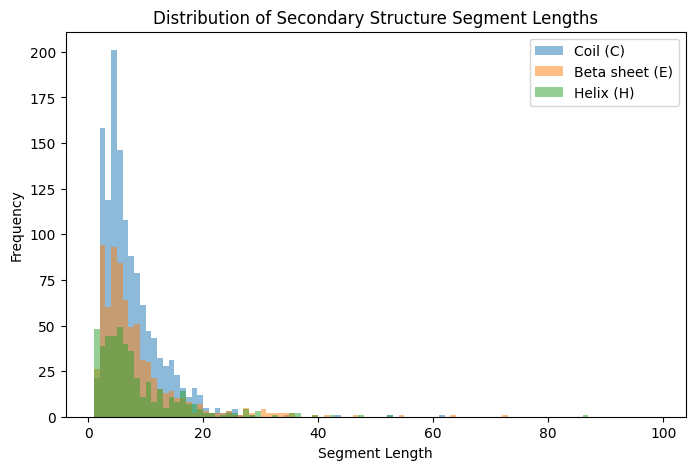

In [ ]:
# Plotting the distributions
plt.figure(figsize=(8, 5))
plt.hist(seq_struct_size[stoken2idx['c']-3], bins=range(1, 100,1), alpha=0.5, label='Coil (C)')
plt.hist(seq_struct_size[stoken2idx['e']-3], bins=range(1, 100,1), alpha=0.5, label='Beta sheet (E)')
plt.hist(seq_struct_size[stoken2idx['h']-3], bins=range(1, 100,1), alpha=0.5, label='Helix (H)')

plt.xlabel('Segment Length')
plt.ylabel('Frequency')
plt.title('Distribution of Secondary Structure Segment Lengths')
plt.legend()
plt.show()

In [ ]:
##Create dataset
from secondary_struct_fcns import create_dataset, pad_sequences
maxSequenceSize = 100

X_train, y_train = create_dataset(aa_train,sh_train, token2idx, stoken2idx, maxProteinSeq=128, maxDataSeq=maxSequenceSize)
X_test , y_test  = create_dataset(aa_test ,sh_test , token2idx, stoken2idx, maxProteinSeq=128, maxDataSeq=maxSequenceSize)
#Pad sequence
dataSeqSize = 130 ##Sequence size to process
X_train = pad_sequences(X_train,token2idx['[PAD]'] ,max_len=dataSeqSize)
y_train = pad_sequences(y_train,stoken2idx['[PAD]'],max_len=dataSeqSize)
X_test  = pad_sequences(X_test ,token2idx['[PAD]'] ,max_len=dataSeqSize)
y_test  = pad_sequences(y_test ,stoken2idx['[PAD]'],max_len=dataSeqSize)



Created data containing 297 sequences.
Created data containing 30 sequences.
Length of the max given sequence:100 padded to:130
Length of the max given sequence:100 padded to:130
Length of the max given sequence:100 padded to:130
Length of the max given sequence:100 padded to:130


In [ ]:
from ProteinTransformer import *

In [ ]:
# # ##Retrieve model with embeddings
import torch.nn as nn
import torch.optim as optim
import torch

trained_model = ProteinTransformer(
    vocab_size=26,
    d_model=256,
    num_heads=8,
    num_layers=4,
    d_ff=1024,
    max_len=130,
    pad_token_id=token2idx["[PAD]"],
    dropout=0.1   # <-- ADDED

)
optimizer       = optim.Adam(trained_model.parameters(), lr=1e-4)

trained_model_file = 'protein_transformer.pt'
checkpoint         = torch.load(trained_model_file, map_location=torch.device('cpu'))
trained_model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']
loss        = checkpoint['loss']
print (f"Model Retrieved: {trained_model_file}. Start epoch:{start_epoch}, loss:{loss}")

Model Retrieved: protein_transformer.pt. Start epoch:60, loss:865.0816032588482


In [ ]:
print (trained_model)

ProteinTransformer(
  (token_emb): Embedding(26, 256)
  (pos_emb): Embedding(130, 256)
  (emb_dropout): Dropout(p=0.1, inplace=False)
  (layers): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attn): MultiHeadSelfAttention(
        (qkv_proj): Linear(in_features=256, out_features=768, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (ff): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=1024, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (mlm_h

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, dataloader, weights, epochs=5):
    model     = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss(weight=weights)

    for epoch in range(epochs):
        total_loss = 0

        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            avg_loss    = total_loss/len(dataloader.dataset)

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f} Avg Loss {avg_loss:4f}")


In [ ]:
##Add Embeddings (emb+positional+normalize)
from torch.utils.data import TensorDataset, DataLoader
##Convert X,y to torch tensors
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)
print(f"X_train:{X_train.shape} y_train:f{y_train.shape}")
print(f"X_test: {X_test.shape}  y_test: f{y_test.shape}")

X_train:(297, 130) y_train:f(297, 130)
X_test: (30, 130)  y_test: f(30, 130)


In [ ]:
import torch.nn.functional as F

samples_size, seq_len = X_train_t.shape
samples_size_test, seq_len_test = X_test_t.shape
print(f"Train samples {samples_size}, sequence length {seq_len}")
print(f"Test  samples {samples_size_test}, sequence length {seq_len_test}")

trained_model = trained_model.to(device)
trained_model.eval()

# ------------------------------
# Extract embeddings from the pretrained model
# ------------------------------
with torch.no_grad():
    X_emb_train = trained_model.token_emb(X_train_t) + trained_model.pos_emb(torch.arange(seq_len, device=device))
    X_emb_test  = trained_model.token_emb(X_test_t) + trained_model.pos_emb(torch.arange(seq_len, device=device))

    for layer in trained_model.layers:
        X_emb_train = layer(X_emb_train)
        X_emb_test  = layer(X_emb_test)

    X_emb_train = trained_model.norm(X_emb_train)
    X_emb_test  = trained_model.norm(X_emb_test)


emb_dim = X_emb_train.shape[-1]

Train samples 297, sequence length 130
Test  samples 30, sequence length 130


In [ ]:
print(f"X with Embeddings \nTrain:{X_emb_train.shape} Test:{X_emb_test.shape}")
print(f"Embedding dimensions {emb_dim}")
print(f"\n{X_train_t[0][0:5]} \n{X_emb_train[0][1][0:5]}")

X with Embeddings 
Train:torch.Size([297, 130, 256]) Test:torch.Size([30, 130, 256])
Embedding dimensions 256

tensor([ 1,  3, 21, 12, 24]) 
tensor([-2.0276,  0.4552,  3.4927,  1.5365,  0.0239])


In [ ]:
y_train.shape, X_emb_train.shape

((297, 130), torch.Size([297, 130, 256]))

####Using LSTM Classifier

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

# ==== CONFIG ====
num_classes = len(stoken2idx)
ignore_idx  = -100

# ==== DATA (assume tensors) ====
# X: (N, 130, 256), y: (N, 130)

# ---- mask unwanted labels ----
pad_id = stoken2idx['[PAD]']
cls_id = stoken2idx['[CLS]']
mask_id= stoken2idx['[MASK]']
def remove_y_classes(y):
  mask_invalid = (y == cls_id) | (y == pad_id) | (y == mask_id)
  y_clean = y.clone()
  y_clean[mask_invalid] = ignore_idx
  return y_clean

y_train_t = remove_y_classes(y_train_t)
y_test_t  = remove_y_classes(y_test_t)


In [ ]:
np.sum(sh_freq), sh_freq

(np.int64(18230), [10084, 3496, 4650])

In [ ]:
y_train_t.shape

torch.Size([297, 130])

In [ ]:
freq    = torch.ones(num_classes) * 1e-8   # small default
fq_wt   = torch.zeros(num_classes)
sh_tot  = np.sum(sh_freq)
for s, f in zip(sh_labels, sh_freq):
    idx = stoken2idx[s]
    freq[idx] = f
    fq_wt[idx]= 1./(f+1e-9)

freq[stoken2idx['[PAD]']] =1
freq[stoken2idx['[CLS]']] =1
freq[stoken2idx['[MASK]']]=1
print(f"sec struct:{sh_labels}")
print('freq  ',freq)
print('fq_wt ',fq_wt)

sec struct:['c', 'e', 'h']
freq   tensor([1.0000e+00, 1.0000e+00, 1.0000e+00, 3.4960e+03, 4.6500e+03, 1.0084e+04])
fq_wt  tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 2.8604e-04, 2.1505e-04, 9.9167e-05])


In [ ]:
batch_size  = 32
lr = 1e-3
# ==== DATASET  ====
train_dataset = TensorDataset(X_emb_train, y_train_t)
test_dataset  = TensorDataset(X_emb_test,  y_test_t)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader    = DataLoader(test_dataset , batch_size=batch_size)

# ==== MODEL ====
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=256, hidden_dim=128, num_classes=6):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.35)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out)
        return self.fc(out)

model = LSTMClassifier(256,256,6)
criterion = nn.CrossEntropyLoss(weight=fq_wt, ignore_index=ignore_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

epochs = 25

# ==== TRAIN LOOP ====
def compute_accuracy(logits, y):
    preds = logits.argmax(dim=-1)
    mask = y != ignore_idx
    correct = (preds[mask] == y[mask]).sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0

for epoch in range(epochs):
    model.train()
    train_loss, train_acc = 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)                      # (B, 130, 6)

        loss = criterion(logits.view(-1, num_classes),
                         yb.view(-1))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_acc += compute_accuracy(logits, yb)

    model.eval()
    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = criterion(logits.view(-1, num_classes),
                             yb.view(-1))

            val_loss += loss.item()
            val_acc += compute_accuracy(logits, yb)


    train_losses.append(train_loss/len(train_loader))
    val_losses  .append(val_loss/len(val_loader))
    train_accs  .append(train_acc/len(train_loader))
    val_accs    .append(val_acc/len(val_loader))

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_losses[-1]:.4f}, "
          f"Train Acc ={train_accs  [-1]:.4f}, "
          f"Val Loss  ={val_losses  [-1]:.4f}, "
          f"Val Acc   ={val_accs    [-1]:.4f}")

Epoch 1: Train Loss=1.1888, Train Acc =0.4584, Val Loss  =0.9515, Val Acc   =0.5712
Epoch 2: Train Loss=0.8005, Train Acc =0.5731, Val Loss  =1.1294, Val Acc   =0.5083
Epoch 3: Train Loss=0.6852, Train Acc =0.6393, Val Loss  =1.1255, Val Acc   =0.5399
Epoch 4: Train Loss=0.5918, Train Acc =0.6875, Val Loss  =1.1839, Val Acc   =0.5200
Epoch 5: Train Loss=0.5196, Train Acc =0.7245, Val Loss  =1.4220, Val Acc   =0.4649
Epoch 6: Train Loss=0.4614, Train Acc =0.7540, Val Loss  =1.5352, Val Acc   =0.4704
Epoch 7: Train Loss=0.4008, Train Acc =0.7875, Val Loss  =1.5511, Val Acc   =0.5145
Epoch 8: Train Loss=0.3414, Train Acc =0.8293, Val Loss  =2.0405, Val Acc   =0.4487
Epoch 9: Train Loss=0.3133, Train Acc =0.8487, Val Loss  =2.1391, Val Acc   =0.4314
Epoch 10: Train Loss=0.2727, Train Acc =0.8605, Val Loss  =1.9752, Val Acc   =0.4895
Epoch 11: Train Loss=0.2385, Train Acc =0.8825, Val Loss  =2.3708, Val Acc   =0.4715
Epoch 12: Train Loss=0.1967, Train Acc =0.9046, Val Loss  =2.5981, Val Acc

In [ ]:
# =======================
# Functions for plotting Accuracy and Loss
# =======================
def plot_loss_acc(numepochs, train_loss, val_loss,train_acc, val_acc, model_name=""):
  epochs_range = np.arange(1, epochs + 1)
  # Create a figure with two subplots (1 row, 2 columns)
  plt.figure(figsize=(10, 5))

  # Plot Loss on the first subplot
  plt.subplot(1, 2, 1)  # (rows, cols, index)
  plt.plot(epochs_range, train_losses, label="Training Loss")
  plt.plot(epochs_range, val_losses, label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Training and Validation Loss")
  plt.legend()

  # Plot Accuracy on the second subplot
  plt.subplot(1, 2, 2)  # (rows, cols, index)
  plt.plot(epochs_range, train_accs, label="Training Accuracy")
  plt.plot(epochs_range, val_accs, label="Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title("Training and Validation Accuracy")
  plt.legend()

  # Display the plots
  plt.tight_layout()  # Adjusts the layout to prevent overlap
  plt.show()

  savefile="loss_acc"
  if model_name != "": savefile = model_name+"_"+savefile
  plt.savefig(f"{savefile}.pdf"); plt.savefig(f"{savefile}.png")


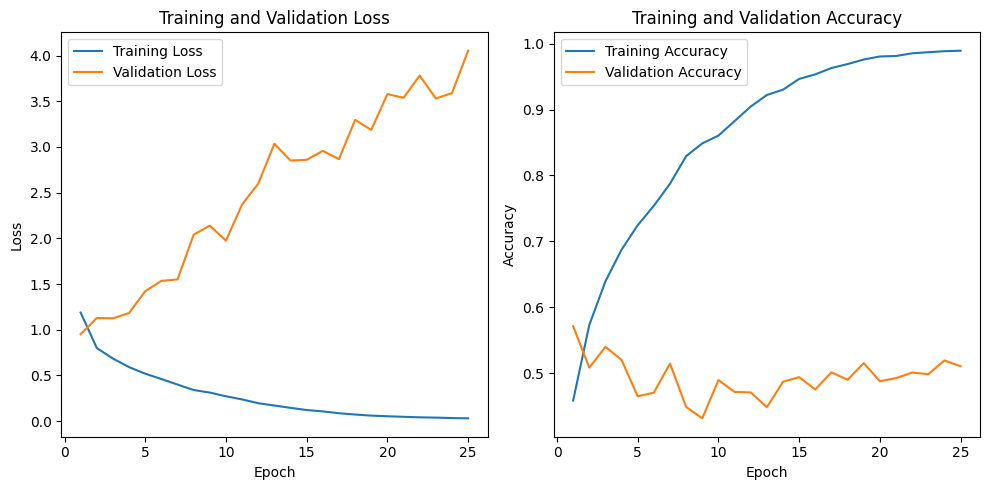

<Figure size 640x480 with 0 Axes>

In [ ]:
##Plot accuracy and loss
plot_loss_acc(epochs, train_losses, val_losses,train_accs, val_accs, model_name="lstm")


####Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        #logits = adjust_logits(logits,tau=1)
        preds = torch.argmax(logits, dim=-1)

        # Only consider masked positions
        mask = y_batch != -100
        all_preds.extend(preds[mask].cpu().numpy())
        all_labels.extend(y_batch[mask].cpu().numpy())

In [ ]:
###Checking Predictions
for i in range(15):
  print(f"Pred: {all_preds[i]:2d}   True: {all_labels[i]:2d}   SecStr:{idx2token[all_preds[i]]}")
#sorted(all_preds)

counts = Counter(all_preds)
print("\nClass frequencies (token index to count):")
for token_idx, count in counts.items():
    print(f"{token_idx:2d}: {count}")

Pred:  5   True:  5   SecStr:C
Pred:  5   True:  5   SecStr:C
Pred:  5   True:  5   SecStr:C
Pred:  5   True:  5   SecStr:C
Pred:  3   True:  3   SecStr:A
Pred:  3   True:  3   SecStr:A
Pred:  5   True:  5   SecStr:C
Pred:  5   True:  5   SecStr:C
Pred:  5   True:  5   SecStr:C
Pred:  5   True:  5   SecStr:C
Pred:  5   True:  4   SecStr:C
Pred:  5   True:  4   SecStr:C
Pred:  5   True:  4   SecStr:C
Pred:  5   True:  4   SecStr:C
Pred:  5   True:  4   SecStr:C

Class frequencies (token index to count):
 5: 1995
 3: 191
 4: 533


In [ ]:
# Overall
acc   = accuracy_score  (all_labels, all_preds)
prec  = precision_score (all_labels, all_preds, average='macro', zero_division=0)
rec   = recall_score    (all_labels, all_preds, average='macro', zero_division=0)
f1    = f1_score        (all_labels, all_preds, average='macro', zero_division=0)

print("=== Overall Metrics ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 score:  {f1:.4f}")

# Creating a summary table
metrics_all_lstm = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall','F1 score'],
    'Value': [acc,prec,rec,f1]
})

=== Overall Metrics ===
Accuracy:  0.5105
Precision: 0.4254
Recall:    0.3865
F1 score:  0.3579


In [ ]:
def make_cm(y_true,y_pred,model_name=""):
  ##Confusion Matrix
  classes = np.unique(all_labels)  # sorted array of token indices
  cm = confusion_matrix(all_labels, all_preds, labels=classes)
  class_names = [list(stoken2idx.keys())[list(stoken2idx.values()).index(c)] for c in classes]

  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=class_names, yticklabels=class_names)

  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title("Confusion Matrix")
  plt.show()
  savefile="confusion_matrix"
  if model_name != "": savefile = model_name+"_"+savefile
  plt.savefig(f"{savefile}.pdf"); plt.savefig(f"{savefile}.png")


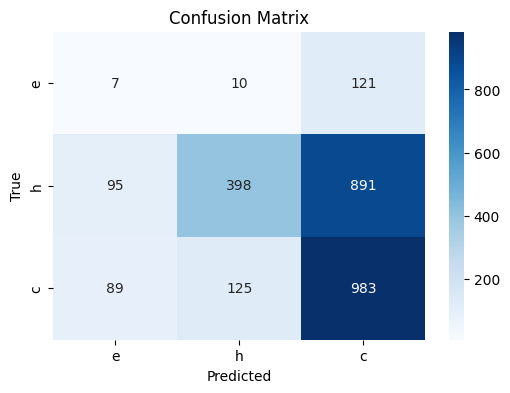

<Figure size 640x480 with 0 Axes>

In [ ]:
make_cm(all_labels,all_preds, "lstm")

In [ ]:
metrics_all_lstm

,Metric,Value
0,Accuracy,0.510482
1,Precision,0.425366
2,Recall,0.386506
3,F1 score,0.357900
